# Inteligência Computacional Aplicada (TIP7077) - Trabalho 1

**Professor**: Guilherme de Alencar Barreto

<img src="https://loop.frontiersin.org/images/profile/243428/203" alt="Foto do Professor" width="150"/>


**Aluno**: Luis Felipe Carneiro de Souza **Matrícula**: 593034

**Objetivos**:

<a href="https://colab.research.google.com/github/LuisFelipeCSouza/inteligencia-computacional-aplicada/blob/main/trabalho-1/main.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm, trange
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import seaborn as sns
import pandas as pd


In [2]:
from pathlib import Path

BASE_DIR = Path("..").resolve().parent
FIG_DIR = BASE_DIR / "tc-1" / "latex" / "figures"

In [3]:
BASE_DIR = Path('..').parent.resolve().parent
DATA_DIR = BASE_DIR / 'trabalho-1' / 'data' / 'Gauss3.csv'

In [4]:
# data = np.loadtxt(DATA_DIR, skiprows=59, max_rows=11, usecols=(0, 1), unpack=True)
data = np.genfromtxt(DATA_DIR, skip_header=1)
data
X = data[:, [1]]
y = data[:, [0]]

## Modelo Polinomial de ordem k.

In [5]:
class PolynomialRegression:
    def __init__(self, degree, lmbda=0.0):
        self.degree = degree
        self.lmbda = lmbda
        self.coefficients = None

    def fit(self, X, y):

        X_poly = self._polymonil_features(X, self.degree)
        I = np.eye(X.shape[1])
        self.coefficients = np.linalg.solve(X_poly.T @ X_poly + self.lmbda * I, X_poly.T @ y)

    def predict(self, X):
        X_poly = self._polymonil_features(X, self.degree)
        return X_poly @ self.coefficients

    def _polymonil_features(self, X, degree):
        m, n = X.shape
        X_poly = np.ones((m, 1))
        for i in range(n):
            x = X[:, i]
            X_poly = np.c_[X_poly, np.vander(x, degree +1, increasing=True)[:, 1:]]
        return X_poly

## Modelo Linear por partes

In [6]:
class PiecewiseLinearRegression:
    def __init__(self, n_pieces=None, knots=None):
        self.n_pieces = n_pieces
        self.knots = knots
        self.coefficients = None

    def fit(self, X, y):

        X_basis_expanded = self._basis_functions(X)

        self.coefficients = np.linalg.solve(X_basis_expanded.T @ X_basis_expanded, X_basis_expanded.T @ y)

    def predict(self, X):

        X_basis_expanded = self._basis_functions(X)

        return X_basis_expanded @ self.coefficients
    
    def _basis_functions(self, X):
        return np.hstack([
            np.ones(X.shape),
            X,
            np.hstack([
            np.column_stack([
                (X >= kl).astype(float),
                (X >= kl).astype(float) * (X - kl)
            ])
            for kl in self.knots
        ])
        ])


## Modelo Spline Linear

In [7]:
class SplineLinearRegression:
    def __init__(self, n_pieces=None, knots=None):
        self.n_pieces = n_pieces
        self.knots = knots
        self.coefficients = None

    def fit(self, X, y):

        X_basis_expanded = self._basis_functions(X)

        self.coefficients = np.linalg.solve(X_basis_expanded.T @ X_basis_expanded, X_basis_expanded.T @ y)

    def predict(self, X):

        X_basis_expanded = self._basis_functions(X)

        return X_basis_expanded @ self.coefficients
    
    def _basis_functions(self, X):
        return np.hstack(
        [
        np.ones(X.shape),
        X,

        *[np.maximum(X - kl, 0) for kl in self.knots],
        ]
        )


## Modelo Fuzzy do tipo Mamdani

In [8]:
class MamdaniFuzzy:
        
    def __init__(self, centers, spread, singleton_outputs):
        self.centers = np.array(centers)
        self.spread = spread
        self.outputs = np.array(singleton_outputs)
        
    def _gaussian_mf(self, x, c, sigma):
        return np.exp(-((x - c) ** 2) / (2 * sigma ** 2))
    
    def predict(self, X):
        X = np.asarray(X)
        y_pred = []
        
        # Iterando sobre cada amostra de entrada
        for j in range(len(X)):
            # As ativações (mi) das regras são os valores de pertinência da velocidade (Passo 6)
            mi = self._gaussian_mf(float(X[j][0]), self.centers, self.spread)
            
            # A saída predita é a média ponderada das potências de saídas das regras (Eq 12, 13, 14)
            y_pred.append(np.sum(mi * self.outputs) / np.sum(mi))
            
        return np.array(y_pred)
    


## Modelo Fuzzy do tipo Katagi-Sugeno

## R2 Score

In [9]:
def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    # Valor médio da potência 
    y_mean = np.mean(y_true)
    
    # Erro de predição do modelo Mamdani (Numerador)
    ss_res = np.sum((y_true - y_pred) ** 2)
    
    # Erro do modelo de predição pela média (Denominador)
    ss_tot = np.sum((y_true - y_mean) ** 2)
    
    # Índice R2
    r2 = 1 - (ss_res / ss_tot)
    return r2


## Conjunto de dados

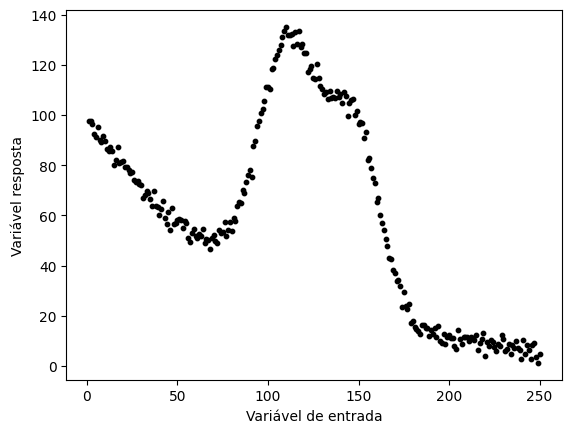

In [14]:
fig, ax = plt.subplots()

ax.scatter(X, y, c='k', s=10)

ax.set_facecolor('none')
fig.patch.set_alpha(0.0)
# ax.set_axis_off()

ax.set_xlabel("Variável de entrada")
ax.set_ylabel("Variável resposta")

plt.savefig(FIG_DIR / "dados.pdf", bbox_inches='tight')

plt.show()

# fig.savefig('data.pdf', transparent=True, bbox_inches='tight')

## Analises

### Modelo polinomial de ordem K

In [232]:
# r2_scores = []
# y_preds = []
# coeffs = []

ks = range(1, 30+1)

results = {f'k={i}': {} for i in ks}

for i in ks:
    
    model1 = PolynomialRegression(i)
    model1.fit(X, y)
    y_pred = model1.predict(X)

    results[f'k={i}']['coeffs'] = model1.coefficients
    results[f'k={i}']['y_pred'] = y_pred
    results[f'k={i}']['r2'] = r2_score(y_true=y, y_pred=y_pred)
    results[f'k={i}']['k'] = i

    # r2_scores.append(r2_score(y_true=y, y_pred=y_pred))

C:\Users\luisx\AppData\Local\Temp\ipykernel_16356\3830509599.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


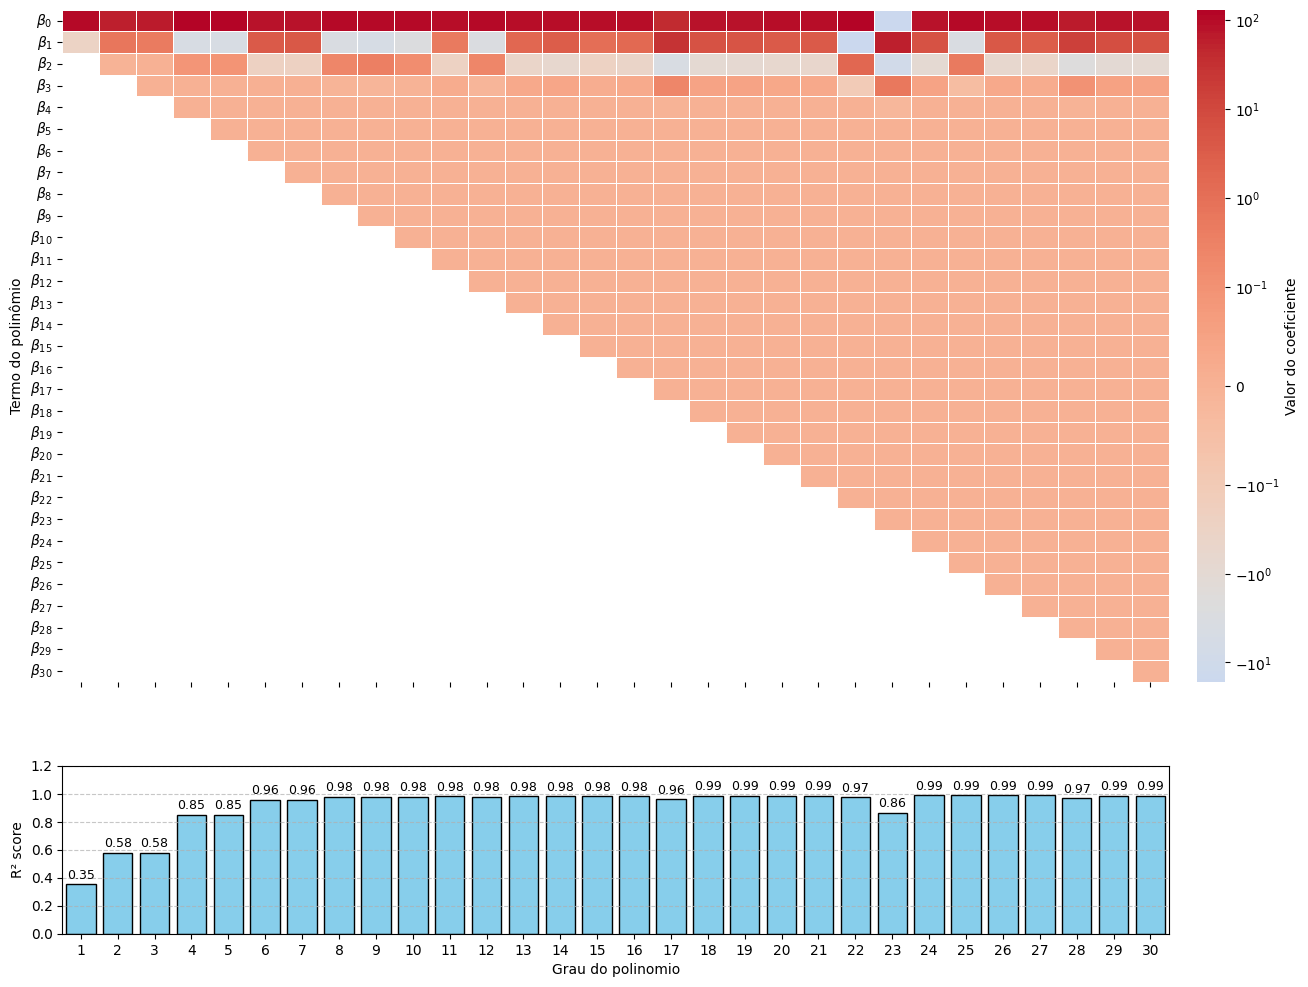

In [ ]:
# 1. Extrai os coeficientes e o R²
coeffs_dict = {}
r2_dict = {}
max_len = 0
for k in ks:
    coeffs = results[f'k={k}']['coeffs']
    coeffs_dict[k] = coeffs
    r2_dict[k] = results[f'k={k}']['r2']
    max_len = max(max_len, len(coeffs))

ks_list = sorted(coeffs_dict.keys())
data = np.full((len(ks_list), max_len), np.nan)
for i, k in enumerate(ks_list):
    c = coeffs_dict[k]
    data[i, :len(c)] = c.ravel()

col_labels = [r'$\beta_0$'] + [fr'$\beta_{{{p}}}$' for p in range(1, max_len)]

# 2. Transpõe a matriz
data_T = data.T
df_rot = pd.DataFrame(data_T, index=col_labels, columns=ks_list)

# ---------------------------------------------------------
# 3. Prepara a figura: GridSpec com 2 linhas e 2 colunas
# Coluna 0: Heatmap (linha 0) e Bar chart (linha 1)
# Coluna 1: Colorbar (linha 0) e Vazio (linha 1)
# ---------------------------------------------------------
fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(
    2, 2, 
    height_ratios=[4, 1],   # Proporção de altura entre Heatmap e Barras
    width_ratios=[40, 1],   # Proporção de largura (Gráficos vs Colorbar)
    wspace=0.05             # Espaço horizontal entre o heatmap e a colorbar
)

ax_heat = fig.add_subplot(gs[0, 0])
cbar_ax = fig.add_subplot(gs[0, 1]) # Eixo exclusivo para a barra de cores
ax_r2   = fig.add_subplot(gs[1, 0]) # Fica na mesma coluna do ax_heat, garantindo a mesma largura

# 4. Heatmap rotacionado
norm = SymLogNorm(linthresh=0.1, linscale=1.0,
                  vmin=df_rot.min().min(), vmax=df_rot.max().max())

# Passamos o cbar_ax explicitamente para o seaborn não encolher o ax_heat
sns.heatmap(df_rot, annot=False, cmap='coolwarm', norm=norm, center=0,
            linewidths=.5, cbar_ax=cbar_ax, cbar_kws={'label': 'Valor do coeficiente'}, ax=ax_heat)

ax_heat.set_ylabel('Termo do polinômio')
ax_heat.set_xlabel('')
ax_heat.tick_params(axis='x', labelbottom=False)

# 5. Gráfico de barras do R² alinhado
x_pos = np.arange(len(ks_list))  
r2_vals = [r2_dict[k] for k in ks_list]
ax_r2.bar(x_pos, r2_vals, width=0.8, color='skyblue', edgecolor='black')
ax_r2.set_xticks(x_pos)
ax_r2.set_xticklabels(ks_list)

# A sua lógica de limites (-0.5 a N-0.5) já é perfeita para alinhar 
# com a forma como o seaborn renderiza as colunas do heatmap
ax_r2.set_xlim(-0.5, len(ks_list) - 0.5) 
ax_r2.set_ylim(0, 1.2)
ax_r2.set_ylabel('R² score')
ax_r2.set_xlabel('Grau do polinomio')
ax_r2.grid(axis='y', linestyle='--', alpha=0.7)

# Adiciona valor do R²
for x, val in zip(x_pos, r2_vals):
    ax_r2.text(x, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# tight_layout não é totalmente compatível com gridspec customizado com cbar_ax, 
# mas se precisar de mais espaço, você pode usar plt.subplots_adjust() ou fig.tight_layout()
fig.tight_layout()

# plt.savefig(FIG_DIR / "poly_result.pdf", bbox_inches='tight')

plt.show()

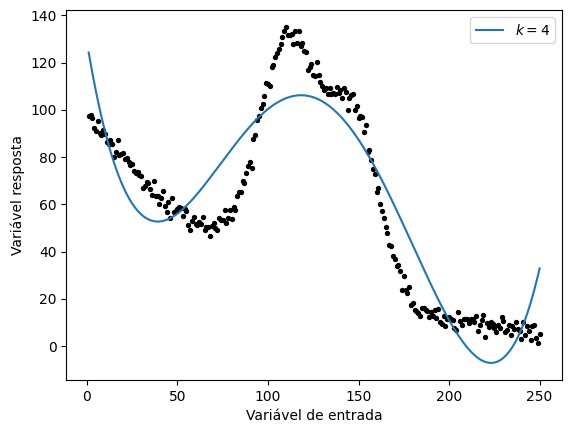

In [26]:
model1 = PolynomialRegression(degree=4)
model1.fit(X, y)
y_pred = model1.predict(X)


fig, ax = plt.subplots()

ax.scatter(X, y, c='k', s=8)

i=4
ax.plot(X, results[f'k={i}']['y_pred'], label=f'$k={i}$')

ax.set_xlabel("Variável de entrada")
ax.set_ylabel("Variável resposta")

ax.legend()

plt.savefig(FIG_DIR / "k4.pdf", bbox_inches='tight')


plt.show()


### Modelo Linear por partes

In [254]:
import numpy as np
from itertools import combinations
import math

def grid_search_knots(modelclass, X, y, num_knots, grid_size=20):
    """
    Busca em grade (Grid Search) para encontrar os melhores nós.
    Testa todas as combinações possíveis dentro de uma grade.
    Ótimo para 1 ou 2 nós.
    """
    x_min, x_max = np.min(X), np.max(X)
    
    # Cria uma grade de pontos, excluindo as bordas extremas para evitar erros
    grid = np.linspace(x_min, x_max, grid_size + 2)[1:-1]
    
    best_r2 = -np.inf
    best_knots = None
    best_coeff = None

    total_iter = math.comb(len(grid), num_knots)
    
    with tqdm(total=total_iter, desc="Grid Search") as pbar:
        # combinations garante que testaremos nós ordenados e sem repetições de conjunto
        for knots_tuple in combinations(grid, num_knots):
            knots = list(knots_tuple)
            model = modelclass(knots=knots)
            
            try:
                model.fit(X, y)
                y_pred = model.predict(X)
                score = r2_score(y, y_pred)
                coeff = model.coefficients
                
                if score > best_r2:
                    best_r2 = score
                    best_knots = (np.round(knots)).tolist()
                    best_coeff = coeff

                    pbar.set_postfix({' R2': f"{best_r2:.4f}"})

            except np.linalg.LinAlgError:
                # Ignora combinações com pontos insuficientes numa partição (matriz singular)
                continue

            pbar.update(1)
            
    return best_knots, best_r2, best_coeff


def random_search_knots(modelclass, X, y, num_knots, num_iterations=500):
    """
    Busca aleatória (Random Search).
    Heurística mais recomendada se você for procurar 3 ou mais nós, 
    pois não cresce de forma explosiva como a busca em grade.
    """
    x_min, x_max = np.min(X), np.max(X)
    
    best_r2 = -np.inf
    best_knots = None
    best_coeff = None


    with tqdm(total=num_iterations, desc="Random Search") as pbar:

        for _ in range(num_iterations):
            # Sorteia valores no intervalo de X e já os deixa ordenados
            knots = sorted(np.random.uniform(x_min, x_max, num_knots))
            model = modelclass(knots=knots)
            
            try:
                model.fit(X, y)
                y_pred = model.predict(X)
                score = r2_score(y, y_pred)
                coeff = model.coefficients
                
                if score > best_r2:
                    best_r2 = score
                    best_knots = (np.round(knots)).tolist()
                    best_coeff = coeff

                    pbar.set_postfix({'R2': f"{best_r2:.4f}"})

            except np.linalg.LinAlgError:
                pass

            pbar.update(1)            
    # print((np.round(best_knots)).tolist())
    return best_knots, best_r2, best_coeff

In [255]:
best_knots_gs, best_r2_gs, best_coeff_gs = grid_search_knots(PiecewiseLinearRegression,X, y, num_knots=5, grid_size=10)
print(f"GRID SEARCH   - Melhores Nós: {best_knots_gs} | R2: {best_r2_gs:.4f}")


Grid Search: 100%|██████████| 252/252 [00:00<00:00, 2763.47it/s,  R2=0.9931]

GRID SEARCH   - Melhores Nós: [69.0, 92.0, 114.0, 159.0, 182.0] | R2: 0.9931


In [256]:
best_knots_rs, best_r2_rs, best_coeff_rs = random_search_knots(SplineLinearRegression, X, y, num_knots=8, num_iterations=4000)
print(f"RANDOM SEARCH - Melhores Nós: {best_knots_rs} | R2: {best_r2_rs:.4f}")

Random Search: 100%|██████████| 4000/4000 [00:00<00:00, 6283.41it/s, R2=0.9950]

RANDOM SEARCH - Melhores Nós: [26.0, 56.0, 81.0, 106.0, 153.0, 170.0, 181.0, 218.0] | R2: 0.9950


#### Busca em grade

In [ ]:
knot_value = range(1, 10+1)

results = {f'knots={i}': {} for i in knot_value}

for i in knot_value:
    best_knots_gs, best_r2_gs, best_coeff_gs = grid_search_knots(PiecewiseLinearRegression, X, y, num_knots=i, grid_size=20)
    results[f'knots={i}']['knots'] = best_knots_gs
    results[f'knots={i}']['r2'] = best_r2_gs


Grid Search: 100%|██████████| 184756/184756 [02:01<00:00, 1526.31it/s,  R2=0.9968]


In [242]:
print(results[f'knots={20}']['knots'])

[38.0, 63.0, 78.0, 86.0, 93.0, 94.0, 98.0, 111.0, 132.0, 134.0, 145.0, 147.0, 153.0, 168.0, 176.0, 179.0, 183.0, 217.0, 224.0, 227.0]


#### Busca aleatória

In [257]:
knot_value = range(1, 10+1)

results = {f'knots={i}': {} for i in knot_value}

for i in knot_value:
    best_knots_rs, best_r2_rs, best_coeff_rs = random_search_knots(PiecewiseLinearRegression, X, y, num_knots=i, num_iterations=4000)
    results[f'knots={i}']['knots'] = best_knots_rs
    results[f'knots={i}']['r2'] = best_r2_rs


Random Search: 100%|██████████| 4000/4000 [00:01<00:00, 2345.29it/s, R2=0.9960]


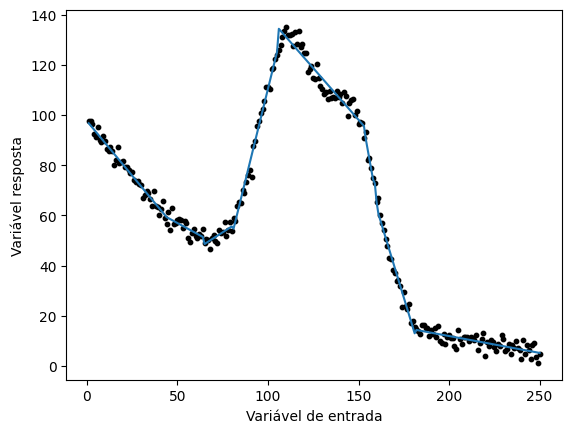

In [84]:
pwreg = PiecewiseLinearRegression(knots=[43.334 , 64.287 , 80.12,  105.688, 153.377, 158.453, 160.324, 181.576])
pwreg.fit(X, y)

y_pred = pwreg.predict(X)

fig, ax = plt.subplots()

ax.scatter(X, y, c='k', s=10)
ax.plot(X, y_pred)

ax.set_facecolor('none')
fig.patch.set_alpha(0.0)
# ax.set_axis_off()

ax.set_xlabel("Variável de entrada")
ax.set_ylabel("Variável resposta")

plt.show()


### Spline

#### Busca aleatória

In [249]:
knot_value = range(1, 10+1)

results = {f'knots={i}': {} for i in knot_value}

for i in knot_value:
    best_knots_rs, best_r2_rs = random_search_knots(SplineLinearRegression, X, y, num_knots=i, num_iterations=4000)
    results[f'knots={i}']['knots'] = best_knots_rs
    results[f'knots={i}']['r2'] = best_r2_rs


Random Search: 100%|██████████| 4000/4000 [00:01<00:00, 2852.37it/s, R2=0.9959]


In [250]:
print(results[f'knots={10}']['knots'])


[34.0, 37.0, 67.0, 83.0, 95.0, 107.0, 108.0, 125.0, 149.0, 179.0]


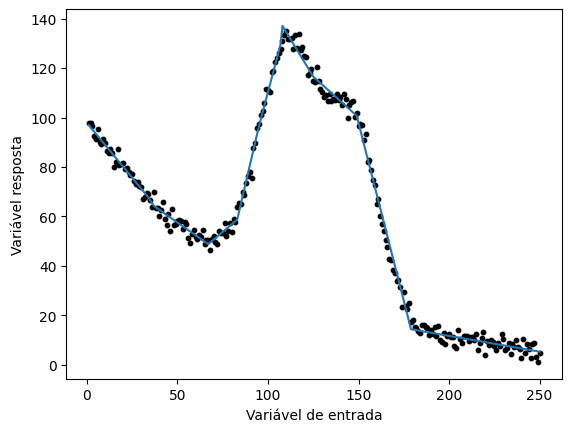

In [251]:
pwreg = SplineLinearRegression(knots=[34.0, 37.0, 67.0, 83.0, 95.0, 107.0, 108.0, 125.0, 149.0, 179.0])
pwreg.fit(X, y)
y_pred = pwreg.predict(X)

fig, ax = plt.subplots()

ax.scatter(X, y, c='k', s=10)
ax.plot(X, y_pred)

ax.set_facecolor('none')
fig.patch.set_alpha(0.0)
# ax.set_axis_off()

ax.set_xlabel("Variável de entrada")
ax.set_ylabel("Variável resposta")

plt.show()


In [215]:
pwreg.coefficients

array([[ 9.80738301e+01],
       [-9.00697710e-01],
       [ 7.00764139e-01],
       [ 3.31662140e+00],
       [-1.51539073e+00],
       [-2.51174997e+00],
       [-2.68193309e+00],
       [ 1.05125349e+00],
       [ 2.38772428e+00],
       [ 2.38301205e-02]])

### Mamdani

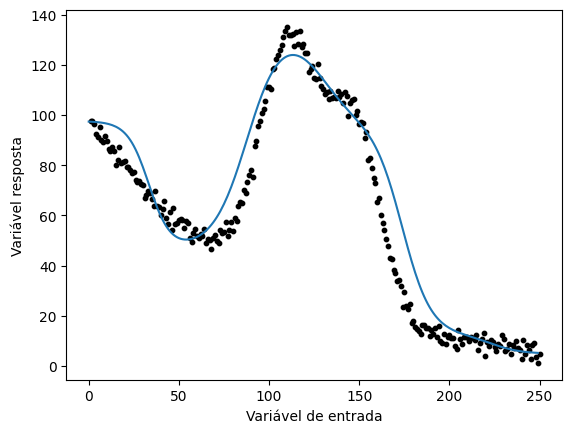

In [16]:

centros = [1, 68, 110, 150, 200, 250]
potencias_saida = [97.58, 46.44, 135.12, 96.44, 12.42, 4.87]
raio = 1.35              
raio = 20

# Instanciando o modelo
modelo_fuzzy = MamdaniFuzzy(centers=centros, spread=raio, singleton_outputs=potencias_saida)

y_pred = modelo_fuzzy.predict(X)
y_pred

# plt.plot(y)
# plt.plot(y_pred)
# plt.scatter(centros, potencias_saida)

fig, ax = plt.subplots()

ax.scatter(X, y, c='k', s=10)

ax.plot(y_pred)

ax.set_facecolor('none')
fig.patch.set_alpha(0.0)
# ax.set_axis_off()

ax.set_xlabel("Variável de entrada")
ax.set_ylabel("Variável resposta")

plt.show()


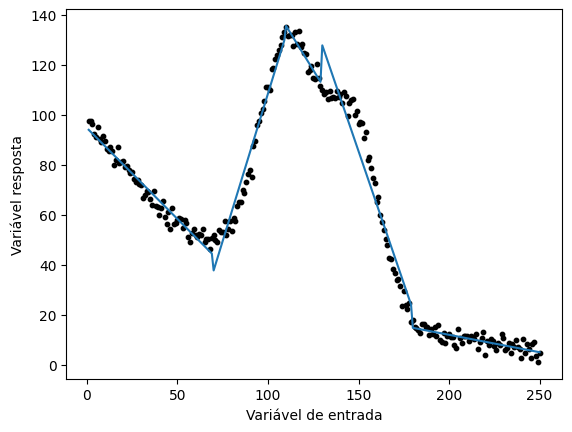

In [17]:
pwreg = PiecewiseLinearRegression(knots=[70, 110, 130, 180])
pwreg.fit(X, y)
y_pred = pwreg.predict(X)

fig, ax = plt.subplots()

ax.scatter(X, y, c='k', s=10)
ax.plot(X, y_pred)

ax.set_facecolor('none')
fig.patch.set_alpha(0.0)
# ax.set_axis_off()

ax.set_xlabel("Variável de entrada")
ax.set_ylabel("Variável resposta")

plt.show()
